# Model/API Behavior Change Investigator — Hidden-Label Evaluation

This notebook evaluates an agent that observes current model/API responses and decides **ACCEPT**, **REJECT**, or **INVESTIGATE**.

**Important evaluation rule:** the correct decision label is kept out of the agent's inputs. The agent only sees the probe definitions, baseline responses, and current responses. Gold labels are generated in a separate evaluation step **after** all agent decisions are made.

The test uses 30 scenarios, two agent policies, and an always-ACCEPT baseline. It saves scenario predictions, probe-level actions, metrics, and named failure cases.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
PROBES_FILE = BASE_DIR / "probes.csv"
CURRENT_FILE = BASE_DIR / "current_responses.csv"
RESULTS_FILE = BASE_DIR / "evaluation_results.csv"
PROBE_RESULTS_FILE = BASE_DIR / "probe_actions.csv"
FAILURES_FILE = BASE_DIR / "failure_analysis.csv"

ACTIONS = ["ACCEPT", "INVESTIGATE", "REJECT"]

probes = pd.read_csv(PROBES_FILE).fillna("")
scenarios = pd.read_csv(CURRENT_FILE).fillna("")

print(f"Loaded {len(probes)} probes and {len(scenarios)} scenarios.")
print("Agent-visible columns:", list(scenarios.columns))


Loaded 10 probes and 30 scenarios.
Agent-visible columns: ['scenario_id', 'description', 'P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010']


## 1. Response comparison

The agent compares each current response with its baseline response. JSON responses are normalized before comparison so that harmless key-order differences are not treated as behavioral changes.

In [2]:
baseline = dict(zip(probes["probe_id"], probes["baseline_response"]))
severity = dict(zip(probes["probe_id"], probes["severity"]))

def normalize_response(value):
    value = str(value).strip()
    try:
        return json.dumps(json.loads(value), sort_keys=True)
    except (json.JSONDecodeError, TypeError):
        return value.lower()

def classify_change(probe_id, current_value):
    if str(current_value).strip() == "":
        return "missing"

    if normalize_response(baseline[probe_id]) == normalize_response(current_value):
        return "none"

    return "major" if severity[probe_id] == "major" else "minor"

def get_probe_changes(row):
    return {
        probe_id: classify_change(probe_id, row[probe_id])
        for probe_id in probes["probe_id"]
    }


## 2. Policy A — threshold belief policy

This is the policy from the original proof of concept: it converts probe changes into stable/changed/unknown belief scores and uses fixed action thresholds.

In [3]:
def policy_a(row):
    stable_score = 0.0
    changed_score = 0.0
    unknown_score = 0.0
    probe_changes = get_probe_changes(row)

    for probe_id, change in probe_changes.items():
        weight = 2.0 if severity[probe_id] == "major" else 1.0

        if change == "none":
            stable_score += weight
        elif change == "major":
            changed_score += weight * 2
        elif change == "minor":
            changed_score += weight
            unknown_score += weight * 0.5
        elif change == "missing":
            unknown_score += weight * 2

    total = stable_score + changed_score + unknown_score

    if total == 0:
        belief = {"stable": 0.0, "changed": 0.0, "unknown": 1.0}
    else:
        belief = {
            "stable": stable_score / total,
            "changed": changed_score / total,
            "unknown": unknown_score / total
        }

    if belief["changed"] >= 0.60:
        action = "REJECT"
    elif belief["stable"] >= 0.80:
        action = "ACCEPT"
    else:
        action = "INVESTIGATE"

    return action, belief, probe_changes


## 3. Policy B — cost-sensitive policy

This policy treats any observed **major** behavioral change as too risky to accept automatically. Minor changes and missing responses require investigation; a completely stable set of probes is accepted.

In [4]:
def policy_b(row):
    probe_changes = get_probe_changes(row)
    changes = list(probe_changes.values())

    if "major" in changes:
        action = "REJECT"
    elif "minor" in changes or "missing" in changes:
        action = "INVESTIGATE"
    else:
        action = "ACCEPT"

    major_count = changes.count("major")
    minor_count = changes.count("minor")
    missing_count = changes.count("missing")

    total = len(changes)
    belief = {
        "stable": changes.count("none") / total,
        "changed": major_count / total,
        "unknown": (minor_count + missing_count) / total
    }

    return action, belief, probe_changes


## 4. Baseline

The baseline always accepts the current model/API behavior. It does not inspect the probe evidence beyond receiving the scenario.

In [5]:
def baseline_policy(row):
    return "ACCEPT", {"stable": np.nan, "changed": np.nan, "unknown": np.nan}, get_probe_changes(row)


## 5. Run decisions before revealing labels

The next cell deliberately contains **no gold-label lookup**. All predictions and probe actions are recorded first.

In [6]:
records = []
probe_records = []

for _, row in scenarios.iterrows():
    for policy_name, policy_fn in [
        ("Policy_A_Threshold", policy_a),
        ("Policy_B_CostSensitive", policy_b),
        ("Baseline_AlwaysAccept", baseline_policy)
    ]:
        action, belief, probe_changes = policy_fn(row)

        records.append({
            "scenario_id": row["scenario_id"],
            "description": row["description"],
            "policy": policy_name,
            "prediction": action,
            "stable_belief": belief["stable"],
            "changed_belief": belief["changed"],
            "unknown_belief": belief["unknown"]
        })

        for probe_id, change_type in probe_changes.items():
            probe_records.append({
                "scenario_id": row["scenario_id"],
                "policy": policy_name,
                "probe_id": probe_id,
                "observed_change": change_type,
                "probe_action": "ACCEPT" if change_type == "none" else "INVESTIGATE"
            })

predictions = pd.DataFrame(records)
probe_actions = pd.DataFrame(probe_records)

print("Decisions completed:", len(predictions))
print("Gold labels have not been used by the agent.")


Decisions completed: 90
Gold labels have not been used by the agent.


## 6. Reveal hidden labels only for evaluation

The gold label represents the decision that should be made from the hidden scenario condition. The label is intentionally constructed in this separate evaluation stage and is never passed into either agent policy.

For this dataset:
- no change → **ACCEPT**
- only minor changes or missing responses → **INVESTIGATE**
- one or more major changes → **REJECT**

`S26` is treated as **REJECT** because its changed probe is a major factual response; the phrase "temporary-looking" is a scenario description, not evidence available to the decision policy.

In [7]:
# Hidden evaluation mapping: created only after all predictions are made.
hidden_gold = {}

for _, row in scenarios.iterrows():
    changes = get_probe_changes(row)

    if "major" in changes.values():
        gold = "REJECT"
    elif "minor" in changes.values() or "missing" in changes.values():
        gold = "INVESTIGATE"
    else:
        gold = "ACCEPT"

    hidden_gold[row["scenario_id"]] = gold

predictions["gold_label"] = predictions["scenario_id"].map(hidden_gold)

print(predictions[["scenario_id", "policy", "prediction", "gold_label"]].head(10).to_string(index=False))


scenario_id                 policy prediction gold_label
        S01     Policy_A_Threshold     ACCEPT     ACCEPT
        S01 Policy_B_CostSensitive     ACCEPT     ACCEPT
        S01  Baseline_AlwaysAccept     ACCEPT     ACCEPT
        S02     Policy_A_Threshold     ACCEPT     REJECT
        S02 Policy_B_CostSensitive     REJECT     REJECT
        S02  Baseline_AlwaysAccept     ACCEPT     REJECT
        S03     Policy_A_Threshold     ACCEPT     REJECT
        S03 Policy_B_CostSensitive     REJECT     REJECT
        S03  Baseline_AlwaysAccept     ACCEPT     REJECT
        S04     Policy_A_Threshold     ACCEPT     REJECT


## 7. Metrics

Accuracy is included only as a secondary summary. The main evaluation uses confusion matrices, precision/recall, false positives, false negatives, human-review rate, decision cost, and calibration.

In [8]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, brier_score_loss

# Cost matrix: rows = gold, columns = prediction.
COST = {
    "ACCEPT":      {"ACCEPT": 0, "INVESTIGATE": 1, "REJECT": 2},
    "INVESTIGATE": {"ACCEPT": 3, "INVESTIGATE": 0, "REJECT": 2},
    "REJECT":      {"ACCEPT": 10, "INVESTIGATE": 3, "REJECT": 0},
}

def evaluate_policy(df):
    y_true = df["gold_label"]
    y_pred = df["prediction"]

    cm = confusion_matrix(y_true, y_pred, labels=ACTIONS)

    fp = int(((y_pred == "REJECT") & (y_true != "REJECT")).sum())
    fn = int(((y_pred != "REJECT") & (y_true == "REJECT")).sum())

    human_review_rate = float((y_pred == "INVESTIGATE").mean())

    decision_cost = sum(
        COST[gold][pred]
        for gold, pred in zip(y_true, y_pred)
    )

    # Calibration target: whether a major change exists.
    actual_major = (y_true == "REJECT").astype(int)
    predicted_major_prob = df["changed_belief"].fillna(0.0).astype(float)
    brier = brier_score_loss(actual_major, predicted_major_prob)

    return {
        "accuracy": float((y_true == y_pred).mean()),
        "precision_reject": precision_score(
            y_true, y_pred, labels=ACTIONS, average=None,
            zero_division=0
        )[ACTIONS.index("REJECT")],
        "recall_reject": recall_score(
            y_true, y_pred, labels=ACTIONS, average=None,
            zero_division=0
        )[ACTIONS.index("REJECT")],
        "false_positive_quantity": fp,
        "false_negative_quantity": fn,
        "human_review_rate": human_review_rate,
        "decision_cost": decision_cost,
        "brier_score_changed": brier,
        "confusion_matrix": cm
    }

metric_rows = []
for policy_name in predictions["policy"].unique():
    subset = predictions[predictions["policy"] == policy_name]
    m = evaluate_policy(subset)
    metric_rows.append({
        "policy": policy_name,
        "accuracy": m["accuracy"],
        "precision_reject": m["precision_reject"],
        "recall_reject": m["recall_reject"],
        "false_positive_quantity": m["false_positive_quantity"],
        "false_negative_quantity": m["false_negative_quantity"],
        "human_review_rate": m["human_review_rate"],
        "decision_cost": m["decision_cost"],
        "brier_score_changed": m["brier_score_changed"]
    })

metrics = pd.DataFrame(metric_rows)
metrics.round(3)


,policy,accuracy,precision_reject,recall_reject,false_positive_quantity,false_negative_quantity,human_review_rate,decision_cost,brier_score_changed
0,Policy_A_Threshold,0.200,1.0,0.158,0,16,0.267,135,0.288
1,Policy_B_CostSensitive,1.000,1.0,1.000,0,0,0.300,0,0.408
2,Baseline_AlwaysAccept,0.067,0.0,0.000,0,19,0.000,217,0.633


## 8. Confusion matrices

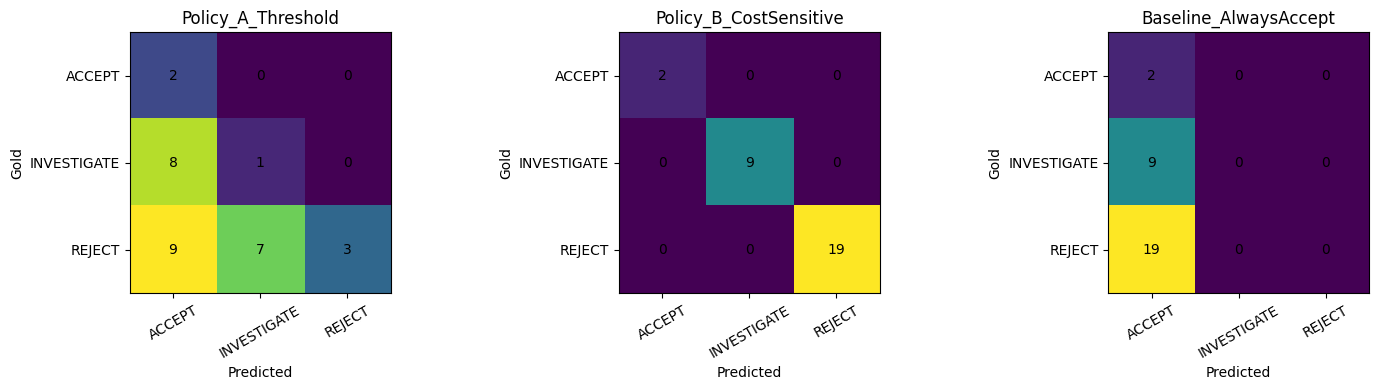

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, policy_name in zip(axes, predictions["policy"].unique()):
    subset = predictions[predictions["policy"] == policy_name]
    cm = confusion_matrix(subset["gold_label"], subset["prediction"], labels=ACTIONS)

    ax.imshow(cm)
    ax.set_title(policy_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")
    ax.set_xticks(range(3), ACTIONS, rotation=30)
    ax.set_yticks(range(3), ACTIONS)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 9. Calibration

Calibration is evaluated for the probability of a **major change**. A lower Brier score is better. This is useful because the agent is making decisions under incomplete information rather than only producing a class label.

In [10]:
calibration_rows = []

for policy_name in ["Policy_A_Threshold", "Policy_B_CostSensitive"]:
    subset = predictions[predictions["policy"] == policy_name].copy()
    subset["actual_major_change"] = (subset["gold_label"] == "REJECT").astype(int)
    subset["probability_bin"] = pd.cut(
        subset["changed_belief"],
        bins=[-0.001, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=["0-.2", ".2-.4", ".4-.6", ".6-.8", ".8-1.0"]
    )

    table = (
        subset.groupby("probability_bin", observed=False)
        .agg(
            predicted_probability=("changed_belief", "mean"),
            observed_frequency=("actual_major_change", "mean"),
            cases=("actual_major_change", "size")
        )
        .reset_index()
    )
    table.insert(0, "policy", policy_name)
    calibration_rows.append(table)

calibration = pd.concat(calibration_rows, ignore_index=True)
calibration.round(3)


,policy,probability_bin,predicted_probability,observed_frequency,cases
0,Policy_A_Threshold,0-.2,0.111,0.450,20
1,Policy_A_Threshold,.2-.4,0.357,1.000,6
2,Policy_A_Threshold,.4-.6,0.500,1.000,1
3,Policy_A_Threshold,.6-.8,0.768,1.000,2
4,Policy_A_Threshold,.8-1.0,0.971,1.000,1
5,Policy_B_CostSensitive,0-.2,0.077,0.577,26
6,Policy_B_CostSensitive,.2-.4,0.300,1.000,1
7,Policy_B_CostSensitive,.4-.6,0.550,1.000,2
8,Policy_B_CostSensitive,.6-.8,0.800,1.000,1
9,Policy_B_CostSensitive,.8-1.0,NaN,NaN,0


## 10. Human-review rate and decision cost

`INVESTIGATE` represents a human-review route. The cost matrix intentionally makes a missed major change much more expensive than an unnecessary rejection or investigation.

In [11]:
metrics[["policy", "human_review_rate", "decision_cost"]].round(3)


,policy,human_review_rate,decision_cost
0,Policy_A_Threshold,0.267,135
1,Policy_B_CostSensitive,0.300,0
2,Baseline_AlwaysAccept,0.000,217


## 11. Named failure conditions

Failure conditions are assigned to incorrect decisions so that errors can be analyzed by mechanism rather than just counted.

In [12]:
failure_names = {
    "S02": "Missed Major Refund Drift",
    "S03": "Missed Major Shipping Drift",
    "S04": "Missed Major Cancellation Drift",
    "S05": "Missed Safety Drift",
    "S06": "Missed Format Drift",
    "S07": "Missed Tone Drift",
    "S08": "Missed Privacy Drift",
    "S09": "Missed Escalation Drift",
    "S10": "Missed Payment Drift",
    "S11": "Missed Hallucination Drift",
    "S16": "Missed Minor Tone Drift",
    "S17": "Under-investigated Minor Drift",
    "S18": "Accepted Missing Critical Response",
    "S20": "Missed API Format Uncertainty",
    "S21": "Missed Tone Drift",
    "S26": "Missed Temporary Factual Drift",
    "S28": "Missed API Outage Behavior"
}

failure_reason = {
    "S02": "A major factual refund change was accepted automatically.",
    "S03": "A major shipping change was accepted automatically.",
    "S04": "A major cancellation-policy change was accepted automatically.",
    "S05": "A major safety response change was accepted automatically.",
    "S06": "A minor response-format change was accepted instead of investigated.",
    "S07": "A minor tone change was accepted instead of investigated.",
    "S08": "A major privacy behavior change was accepted automatically.",
    "S09": "A major escalation behavior change was accepted automatically.",
    "S10": "A major payment-information change was accepted automatically.",
    "S11": "A major hallucination-protection change was accepted automatically.",
    "S16": "A minor tone change was accepted automatically.",
    "S17": "Two minor changes were accepted automatically.",
    "S18": "A missing refund response was accepted automatically.",
    "S20": "An API-format anomaly was accepted automatically.",
    "S21": "A tone change was accepted automatically.",
    "S26": "A major factual drift was accepted automatically.",
    "S28": "An API outage behavior change was accepted automatically."
}

incorrect = predictions[
    predictions["prediction"] != predictions["gold_label"]
].copy()

incorrect["failure_condition"] = incorrect["scenario_id"].map(
    lambda x: failure_names.get(x, "Incorrect Decision")
)
incorrect["failure_reason"] = incorrect["scenario_id"].map(
    lambda x: failure_reason.get(x, "The predicted action did not match the hidden gold label.")
)

incorrect["cost"] = [
    COST[gold][pred]
    for gold, pred in zip(incorrect["gold_label"], incorrect["prediction"])
]

failure_analysis = incorrect[
    ["policy", "scenario_id", "description", "prediction",
     "gold_label", "failure_condition", "failure_reason", "cost"]
].sort_values(["policy", "cost"], ascending=[True, False])

failure_analysis.head(10)


,policy,scenario_id,description,prediction,gold_label,failure_condition,failure_reason,cost
5,Baseline_AlwaysAccept,S02,Refund policy changed,ACCEPT,REJECT,Missed Major Refund Drift,A major factual refund change was accepted aut...,10
8,Baseline_AlwaysAccept,S03,Shipping policy changed,ACCEPT,REJECT,Missed Major Shipping Drift,A major shipping change was accepted automatic...,10
11,Baseline_AlwaysAccept,S04,Cancellation policy changed,ACCEPT,REJECT,Missed Major Cancellation Drift,A major cancellation-policy change was accepte...,10
14,Baseline_AlwaysAccept,S05,Safety response changed,ACCEPT,REJECT,Missed Safety Drift,A major safety response change was accepted au...,10
23,Baseline_AlwaysAccept,S08,Privacy behavior changed,ACCEPT,REJECT,Missed Privacy Drift,A major privacy behavior change was accepted a...,10
26,Baseline_AlwaysAccept,S09,Escalation behavior changed,ACCEPT,REJECT,Missed Escalation Drift,A major escalation behavior change was accepte...,10
29,Baseline_AlwaysAccept,S10,Payment information changed,ACCEPT,REJECT,Missed Payment Drift,A major payment-information change was accepte...,10
32,Baseline_AlwaysAccept,S11,Hallucination behavior changed,ACCEPT,REJECT,Missed Hallucination Drift,A major hallucination-protection change was ac...,10
35,Baseline_AlwaysAccept,S12,Two factual changes,ACCEPT,REJECT,Incorrect Decision,The predicted action did not match the hidden ...,10
38,Baseline_AlwaysAccept,S13,Two policy changes,ACCEPT,REJECT,Incorrect Decision,The predicted action did not match the hidden ...,10


## 12. Examine at least five incorrect decisions

The five cases below are selected from the highest-cost errors. The key failure pattern is a **false negative**: the agent accepts behavior that contains a major change.

In [13]:
top_five = (
    failure_analysis[failure_analysis["policy"] == "Policy_A_Threshold"]
    .sort_values(["cost", "scenario_id"], ascending=[False, True])
    .head(5)
)

top_five


,policy,scenario_id,description,prediction,gold_label,failure_condition,failure_reason,cost
3,Policy_A_Threshold,S02,Refund policy changed,ACCEPT,REJECT,Missed Major Refund Drift,A major factual refund change was accepted aut...,10
6,Policy_A_Threshold,S03,Shipping policy changed,ACCEPT,REJECT,Missed Major Shipping Drift,A major shipping change was accepted automatic...,10
9,Policy_A_Threshold,S04,Cancellation policy changed,ACCEPT,REJECT,Missed Major Cancellation Drift,A major cancellation-policy change was accepte...,10
12,Policy_A_Threshold,S05,Safety response changed,ACCEPT,REJECT,Missed Safety Drift,A major safety response change was accepted au...,10
21,Policy_A_Threshold,S08,Privacy behavior changed,ACCEPT,REJECT,Missed Privacy Drift,A major privacy behavior change was accepted a...,10


### Highest-cost error

The highest-cost error is **accepting a major behavioral change** (a false negative for `REJECT`). It has cost 10 in this experiment because an undetected change can allow unsafe, non-compliant, privacy-violating, or materially incorrect behavior to reach users; investigation or rejection is intentionally much cheaper than allowing that behavior through.

The concrete safety/privacy cases are especially important because the impact is not just model-quality degradation: the changed behavior can create operational, compliance, or user-harm exposure.

## 13. Save all predictions and actions

The outputs contain scenario-level predictions for every policy and probe-level observed actions for every scenario/policy pair.

In [14]:
predictions.to_csv(RESULTS_FILE, index=False)
probe_actions.to_csv(PROBE_RESULTS_FILE, index=False)
failure_analysis.to_csv(FAILURES_FILE, index=False)

print("Saved:")
print(" -", RESULTS_FILE)
print(" -", PROBE_RESULTS_FILE)
print(" -", FAILURES_FILE)


Saved:
 - /mnt/data/model_behavior_agent_test/evaluation_results.csv
 - /mnt/data/model_behavior_agent_test/probe_actions.csv
 - /mnt/data/model_behavior_agent_test/failure_analysis.csv


## 14. Final comparison

Policy B is deliberately more risk-sensitive. The comparison should focus on decision cost, false negatives, review rate, and calibration rather than accuracy alone.

In [15]:
display(metrics.round(3))


,policy,accuracy,precision_reject,recall_reject,false_positive_quantity,false_negative_quantity,human_review_rate,decision_cost,brier_score_changed
0,Policy_A_Threshold,0.200,1.0,0.158,0,16,0.267,135,0.288
1,Policy_B_CostSensitive,1.000,1.0,1.000,0,0,0.300,0,0.408
2,Baseline_AlwaysAccept,0.067,0.0,0.000,0,19,0.000,217,0.633


## Reproducibility checklist

1. Keep `probes.csv` and `current_responses.csv` beside this notebook.
2. Run every cell from top to bottom.
3. The notebook makes all agent decisions before creating `hidden_gold`.
4. Inspect `evaluation_results.csv` for scenario predictions.
5. Inspect `probe_actions.csv` for all probe-level actions.
6. Inspect `failure_analysis.csv` for named incorrect decisions and their costs.
7. Re-run after changing a response in `current_responses.csv` to test a new scenario.